<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_2_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

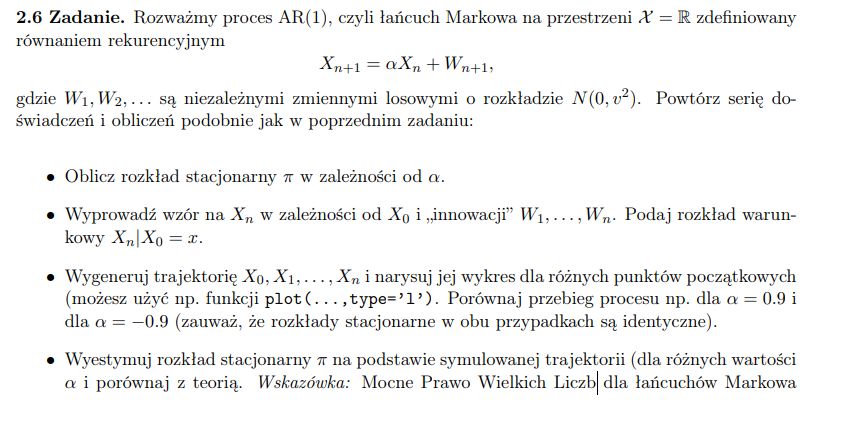

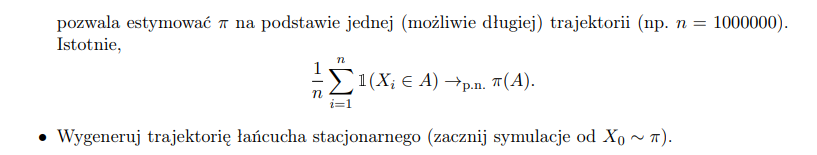

### Stationary and conditional distribution
-----


Let us write a few first random variables $X_i$:

$$X_1 = \alpha X_0 + W_1$$$$X_2 = \alpha X_1 + W_2 = \alpha(\alpha X_0 + W_1) + W_2 = \alpha^2 X_0 + \alpha W_1 + W_2$$$$X_3 = \alpha X_2 + W_3 = \alpha(\alpha^2 X_0 + \alpha W_1 + W_2) + W_3 = \alpha^3 X_0 + \alpha^2 W_1 + \alpha W_2 + W_3$$

Now, it's easy to see that:

$$X_n = \alpha^n X_0 + \sum_{i=1}^n \alpha^{n-i} W_i$$

(it can be showed by applying easy proof by induction).

* **Conditional distribution $X_n | X_0=x$**

$$
\mathbb{E}[X_n | X_0=x] = \mathbb{E}[\alpha^n x + \sum_{i=1}^n \alpha^{n-i} W_i] = \alpha^n x + 0  = \alpha^n x
$$

$
\text{Var}(X_n | X_0 = x) = \text{Var}(\sum_{i=1}^n \alpha^{n-i} W_i) = \sum_{i=1}^n (\alpha^{n-i})^2 \text{Var}(W_i) = v^2 \sum_{j=0}^{n-1} \alpha^{2j} = v^2 \frac{1-\alpha^{2n}}{1-\alpha^2}
$

Given $X_0 = x$, $X_n$ is a linear combination of independent Gaussian random variables, therefore its conditional distribution is also Gaussian:

$$X_n | X_0 = x \sim N\left(\alpha^n x, \ v^2 \frac{1 - \alpha^{2n}}{1 - \alpha^2}\right)$$

* **Stationary distribution**

The stationary distribution can be derived by taking the limit as $n \to \infty$ of the previously derived conditional distribution. It is crucial to assume that $|\alpha| < 1$, because otherwise the process would explode.

As $n \to \infty$:

$$\alpha^n x → 0$$

$$ v^2 \frac{1 - \alpha^{2n}}{1 - \alpha^2} \rightarrow \frac{v^2}{1-\alpha^2}$$

Therefore, the stationary distribution $\pi$ is:

$$\pi=N\left(0, \  \frac{v^2}{1 - \alpha^2}\right)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def sampler(x0=0, n=100, alpha=0.9, v=1):
  trajectory = [x0]
  for i in range(n):
    w = np.random.randn()
    trajectory.append(alpha * trajectory[-1] + w * v)
  return trajectory

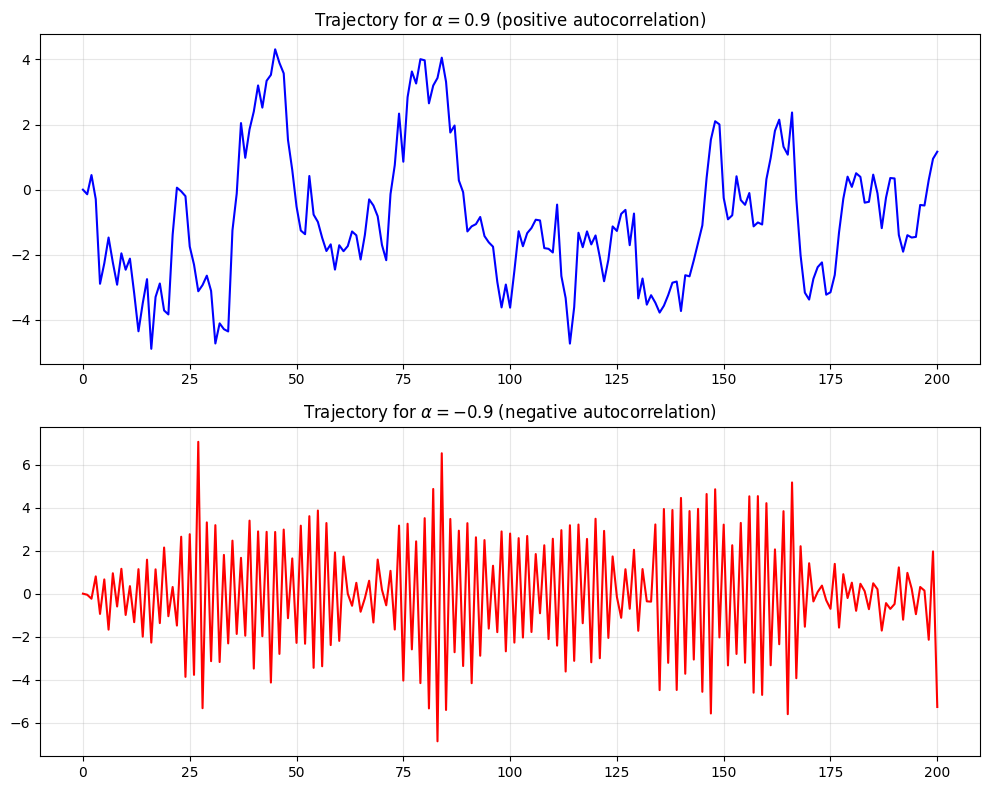

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

traj_pos = sampler(n=200, alpha=0.9, v=1, x0=0.0)
ax1.plot(traj_pos, color='blue', linewidth=1.5)
ax1.set_title(r"Trajectory for $\alpha = 0.9$ (positive autocorrelation)")
ax1.grid(True, alpha=0.3)

traj_neg = sampler(n=200, alpha=-0.9, v=1, x0=0.0)
ax2.plot(traj_neg, color='red', linewidth=1.5)
ax2.set_title(r"Trajectory for $\alpha = -0.9$ (negative autocorrelation)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

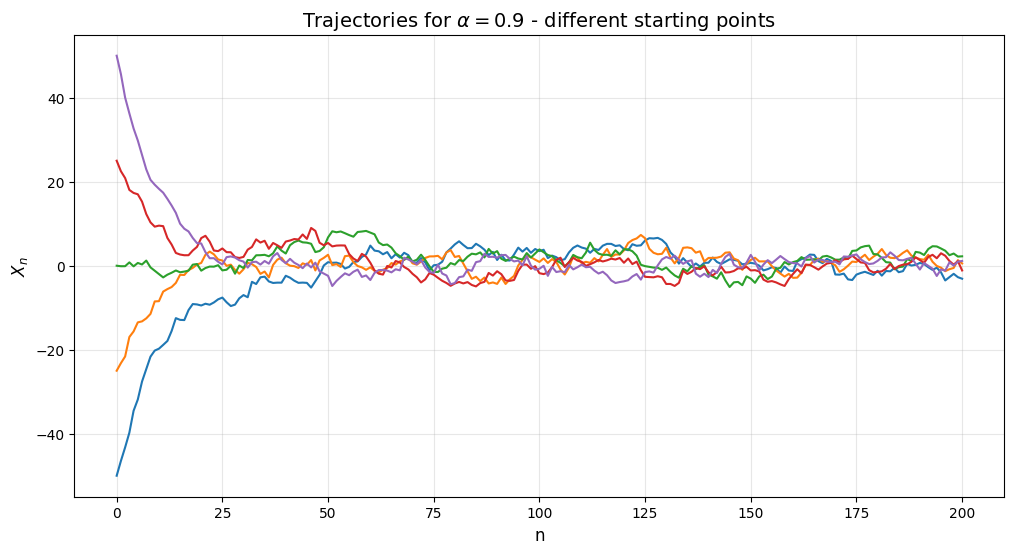

In [16]:
starts = [-50, -25, 0, 25, 50]
trajectories = []

for start in starts:
  traj = sampler(n=200, alpha=0.9, v=1, x0=start)
  trajectories.append(traj)

plt.figure(figsize=(12,6))
for i in range(len(starts)):
  plt.plot(range(201), trajectories[i])
plt.title(r'Trajectories for $\alpha = 0.9$ - different starting points', fontsize=14)
plt.xlabel('n', fontsize=12)
plt.ylabel(r'$X_n$', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


Theoretical mean: 0.0000 | Estimated mean: -0.0067
Theoretical variance: 5.2632 | Estimated variance: 5.2885


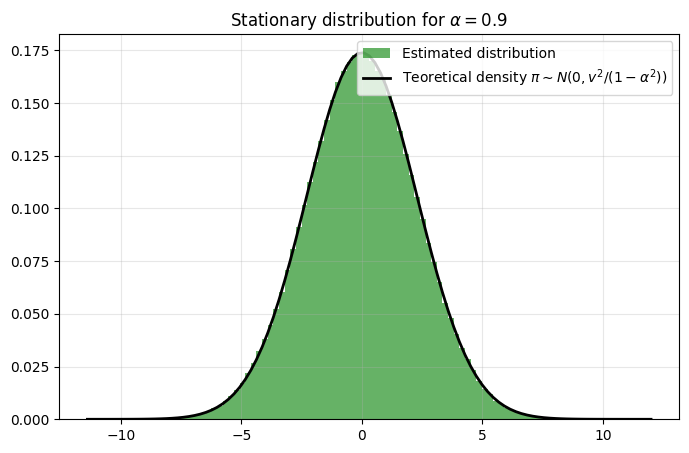

In [17]:
n = 1000000
alpha = 0.9
v = 1.0


long_traj = sampler(n=n, alpha=alpha, v=v, x0=0.0)

# burnout
long_traj_stationary = long_traj[1000:]

# theoretical parameters
mean_theory = 0.0
var_theory = (v**2) / (1 - alpha**2)
std_theory = np.sqrt(var_theory)

# estimated parameters
empir_mean = np.mean(long_traj_stationary)
empir_var = np.var(long_traj_stationary)

print(f"Theoretical mean: {mean_theory:.4f} | Estimated mean: {empir_mean:.4f}")
print(f"Theoretical variance: {var_theory:.4f} | Estimated variance: {empir_var:.4f}")

# Histogram with empirical distribution + density of theoretical distribution
plt.figure(figsize=(8, 5))
count, bins, ignored = plt.hist(long_traj_stationary, bins=100, density=True, alpha=0.6, color='green', label="Estimated distribution")

pdf_teoret = 1/(std_theory * np.sqrt(2 * np.pi)) * np.exp(- (bins - mean_theory)**2 / (2 * var_theory))
plt.plot(bins, pdf_teoret, linewidth=2, color='black', label=r"Teoretical density $\pi \sim N(0, v^2/(1-\alpha^2))$")

plt.title(f"Stationary distribution for $\\alpha = {alpha}$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_938/3322862094.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Trajectory of stationary chain (Start $X_0 \sim \pi$, $X_0 = {x0:.2f}$)")


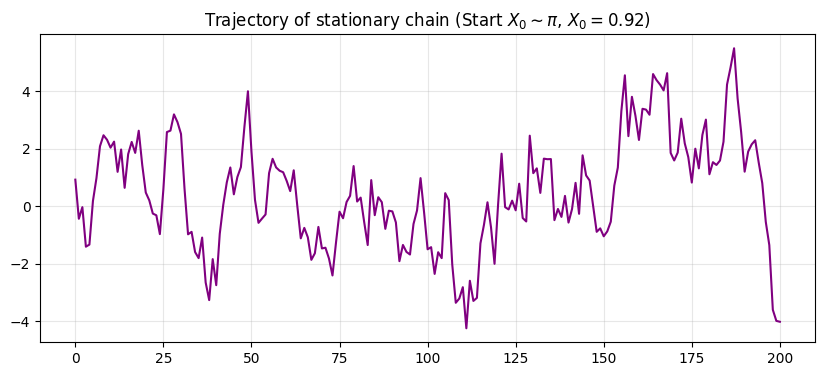

In [19]:
x0 = np.random.normal(loc=0.0, scale=std_theory)

traj_stacjonarna = sampler(n=200, alpha=alpha, v=v, x0=x0)

plt.figure(figsize=(10, 4))
plt.plot(traj_stacjonarna, color='purple', linewidth=1.5)
plt.title(f"Trajectory of stationary chain (Start $X_0 \sim \pi$, $X_0 = {x0:.2f}$)")
plt.grid(True, alpha=0.3)
plt.show()